# Antarctic SMB Reconstruction — **MAR** version (1801–2017)\n\nSame method as the RACMO reconstruction, but the prior is **MAR v3.6.4** (35 km, ERA-Interim, 1979–2017). Setup cells load MAR SMB + grid and remap the IMBIE basins onto the 35 km grid, keeping the *same variable names* so the model-agnostic downstream (EnSRF, LTV, GGM, attribution) is reused unchanged. Water-isotope cores and the temperature sensitivity use **RACMO T2m regridded onto the MAR grid** as a stand-in (option B), since MAR temperature was not available. Recent-era endpoints are 2017 (MAR's coverage).

## 1 · Setup and data (MAR)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
from scipy import stats
from scipy.spatial import cKDTree
from sklearn.linear_model import LinearRegression


In [2]:
data_dir = os.path.expanduser("~/DataFiles")
racmo_smb_file = data_dir + "/smbgl_monthlyS_ANT11_RACMO2.4p1_ERA5_197901_202512.nc"
racmo_t2m_file = data_dir + "/tas_monthlyA_ANT11_RACMO2.4p1_ERA5_197901_202512.nc"
racmo_mask_file = data_dir + "/TotIS_RACMO_ANT27_IMBIE2.nc"
ant11_mask_file = data_dir + "/ANT11_masks.nc"
ant27_ref_file  = data_dir + "/smb_monthlyS_ANT27_ERA5-3H_RACMO2.3p2_197901_202212.nc"
accum_data_file   = data_dir + "/AccumCoresData.csv"
water_data_file   = data_dir + "/WaterCoresData.csv"
accum_coords_file = data_dir + "/AccumCoresCoords.csv"
water_coords_file = data_dir + "/WaterCoresCoords.csv"


In [3]:
# ===== MAR v3.6.4 SMB (ice sector, grounded) + RACMO T2m regridded to the MAR grid =====
_ME = data_dir + "/MAR_extract/MARv3.6.4-Antarctica/ERA-Interim/"
_g  = xr.open_dataset(_ME + "MAR-ant35km-grid.nc")
_sm = xr.open_dataset(_ME + "MAR-ERA-Interim_smb_1979-2017_annual.nc4")
lat_racmo, lon_racmo = _g["LAT"].values, _g["LON"].values          # (name kept; now the MAR 35 km grid)
NY, NX = lat_racmo.shape
MAR_AREA  = _g["AREA"].values                                       # projection area factor (~1)
MAR_gfrac = np.clip(_g["GROUND"].values / 100.0, 0, 1)             # grounded-ice fraction per cell
_smbv = _sm["smb"].isel(sector=1).values                           # ice sector, kg m-2 yr-1 (mmWE)
_smbv = np.where(np.isfinite(_smbv), _smbv, np.nan)
years_obs = pd.DatetimeIndex(_sm["time"].values).year.values       # 1979-2017
smb_ann = xr.DataArray(_smbv, dims=["year","y","x"], coords={"year": years_obs})

def to_xyz(lat, lon):
    la, lo = np.deg2rad(lat), np.deg2rad(lon)
    return np.stack([np.cos(la)*np.cos(lo), np.cos(la)*np.sin(lo), np.sin(la)], -1)

# RACMO 2 m temperature -> nearest MAR cell (stand-in T2m for the water-isotope PSM & attribution)
_t2 = xr.open_dataset(racmo_t2m_file)["tas"].squeeze("height").groupby("time.year").mean("time").sel(year=slice(1979,2025))
_latT, _lonT = _t2["lat"].values, _t2["lon"].values; _ty = _t2["year"].values
_, _jj = cKDTree(to_xyz(_latT.ravel(), _lonT.ravel())).query(to_xyz(lat_racmo.ravel(), lon_racmo.ravel()))
t2m_ann = xr.DataArray(_t2.values.reshape(len(_ty), -1)[:, _jj].reshape(len(_ty), NY, NX),
                       dims=["year","y","x"], coords={"year": _ty})
print("MAR grid:", (NY, NX), " SMB years", int(years_obs.min()), "-", int(years_obs.max()))


MAR grid: (171, 201)  SMB years 1979 - 2017


In [4]:
# ===== MAR grounded mask + IMBIE basins (remapped from the ant27 GroundedIce field) =====
cell_area_m2 = (35_000.0**2) * MAR_AREA * MAR_gfrac                 # grounded-effective cell area (m^2)
grounded_mask = MAR_gfrac > 0
ice_sheet = (np.clip(_g["ICE"].values / 100.0, 0, 1) > 0)
_gi  = xr.open_dataset(racmo_mask_file)["GroundedIce"].values
_r27 = xr.open_dataset(ant27_ref_file)["smb"].squeeze("height"); _lat27, _lon27 = _r27["lat"].values, _r27["lon"].values
_gi  = np.where(np.isfinite(_gi), _gi, 0).astype(int); _gm = _gi > 0
_, _bidx = cKDTree(to_xyz(_lat27[_gm], _lon27[_gm])).query(to_xyz(lat_racmo.ravel(), lon_racmo.ravel()))
_nb = _gi[_gm][_bidx].reshape(NY, NX)
basin_mask = np.where(grounded_mask & np.isfinite(_smbv).all(0), _nb, 0)
basin_flat = basin_mask.reshape(-1); valid_cells = basin_flat > 0
basin_ids  = basin_flat[valid_cells].astype(int); basin_ids_unique = np.unique(basin_ids)
region_names = ["AIS", "WAIS", "EAIS", "AP"]
print("grounded cells:", int(valid_cells.sum()))


grounded cells: 10778


In [5]:
def basin_sums_Gt(field3d, years):
    mass = field3d * cell_area_m2
    df = pd.DataFrame(index=list(np.asarray(years)), columns=basin_ids_unique, dtype=float)
    for t, yr in enumerate(np.asarray(years)):
        flat = mass[t].reshape(-1)[valid_cells]
        s = pd.DataFrame({"basin": basin_ids, "m": flat}).groupby("basin")["m"].sum() / 1e12
        df.loc[yr, s.index] = s.values
    return df


In [6]:
smb_basin_obs = basin_sums_Gt(smb_ann.values, years_obs)
ais_rac  = smb_basin_obs.sum(axis=1).astype(float)
wais_rac = smb_basin_obs[[3,7,8,9,10]].sum(axis=1).astype(float)
eais_rac = smb_basin_obs[[1,2,11,12,13,14,15,16,17,18]].sum(axis=1).astype(float)
ap_rac   = smb_basin_obs[[4,5,6]].sum(axis=1).astype(float)
raw_series = {"AIS": ais_rac, "WAIS": wais_rac, "EAIS": eais_rac, "AP": ap_rac}


## 2 · Ice cores and PSMs\nAccumulation cores: identity PSM onto MAR SMB. Water-isotope cores: regression onto RACMO T2m (regridded to MAR). Calibration window 1979–2016 (N=38).

In [7]:
accum_data_raw = pd.read_csv(accum_data_file, header=None)
water_data_raw = pd.read_csv(water_data_file, header=None)
def extract_cores(raw_df, yr_min, yr_max, transpose=True):
    years_col = raw_df.iloc[2:, 0].astype(int)
    m = (years_col >= yr_min) & (years_col <= yr_max)
    arr = raw_df.iloc[2:, 1:][m].to_numpy()[::-1].astype(float)
    return arr.T if transpose else arr
N_CAL = 38; CAL_YEARS = slice(1979, 2016); recon_years = np.arange(1801, 2001)
accum_cores_cal  = extract_cores(accum_data_raw, 1979, 2016)
water_cores_cal  = extract_cores(water_data_raw, 1979, 2016)
accum_cores_full = extract_cores(accum_data_raw, 1801, 2000, transpose=False)
water_cores_full = extract_cores(water_data_raw, 1801, 2000, transpose=False)
accum_coords = pd.read_csv(accum_coords_file, header=None)
water_coords = pd.read_csv(water_coords_file, header=None)
core_lats  = accum_coords.iloc[:, 2].values; core_lons  = (accum_coords.iloc[:, 3].values + 360) % 360
water_lats = water_coords.iloc[:, 2].values; water_lons = (water_coords.iloc[:, 3].values + 360) % 360
print("accum cores:", accum_cores_full.shape[1], " water cores:", water_cores_full.shape[1])


accum cores: 84  water cores: 80


In [8]:
def nearest_ij(lat2d, lon2d, tlat, tlon):
    lon360 = (lon2d + 360) % 360
    d2 = (lat2d - tlat)**2 + (lon360 - (tlon + 360) % 360)**2
    return np.unravel_index(np.argmin(d2), d2.shape)
smb_cal = smb_ann.sel(year=CAL_YEARS).values; t2m_cal = t2m_ann.sel(year=CAL_YEARS).values
accum_pts = np.zeros((84, N_CAL)); R_accum = np.zeros(84)
for i in range(84):
    j, k = nearest_ij(lat_racmo, lon_racmo, core_lats[i], core_lons[i])
    smb_pt = smb_cal[:, j, k]; obs = accum_cores_cal[i, :]; accum_pts[i, :] = smb_pt
    v = np.isfinite(obs) & np.isfinite(smb_pt)
    reg = LinearRegression().fit(smb_pt[v].reshape(-1,1), obs[v].reshape(-1,1))
    R_accum[i] = np.var(obs[v].reshape(-1,1) - reg.predict(smb_pt[v].reshape(-1,1)), ddof=1)
_valid = np.isfinite(accum_cores_cal) & np.isfinite(accum_pts)
_off = (np.nanmean(np.where(_valid, accum_cores_cal, np.nan), axis=1)
        - np.nanmean(np.where(_valid, accum_pts, np.nan), axis=1))
y_e_accum = accum_pts + _off[:, None]
y_e_water = np.zeros((80, N_CAL)); R_water = np.zeros(80)
for i in range(80):
    j, k = nearest_ij(lat_racmo, lon_racmo, water_lats[i], water_lons[i])
    t_pt = t2m_cal[:, j, k]; obs = water_cores_cal[i, :]
    v = np.isfinite(obs) & np.isfinite(t_pt)
    reg = LinearRegression().fit(t_pt[v].reshape(-1,1), obs[v].reshape(-1,1))
    y_e_water[i, :] = t_pt * reg.coef_[0][0] + reg.intercept_[0]
    R_water[i] = np.var(obs[v].reshape(-1,1) - reg.predict(t_pt[v].reshape(-1,1)), ddof=1)
y_e_smb = np.vstack([y_e_accum, y_e_water]); R_smb_diag = np.concatenate([R_accum, R_water])
proxy_smb = np.hstack([accum_cores_full, water_cores_full])
print("PSMs ready:", y_e_smb.shape)


PSMs ready: (164, 38)


/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/opt/anaconda3/envs/xesmf-env/lib/python3.10/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


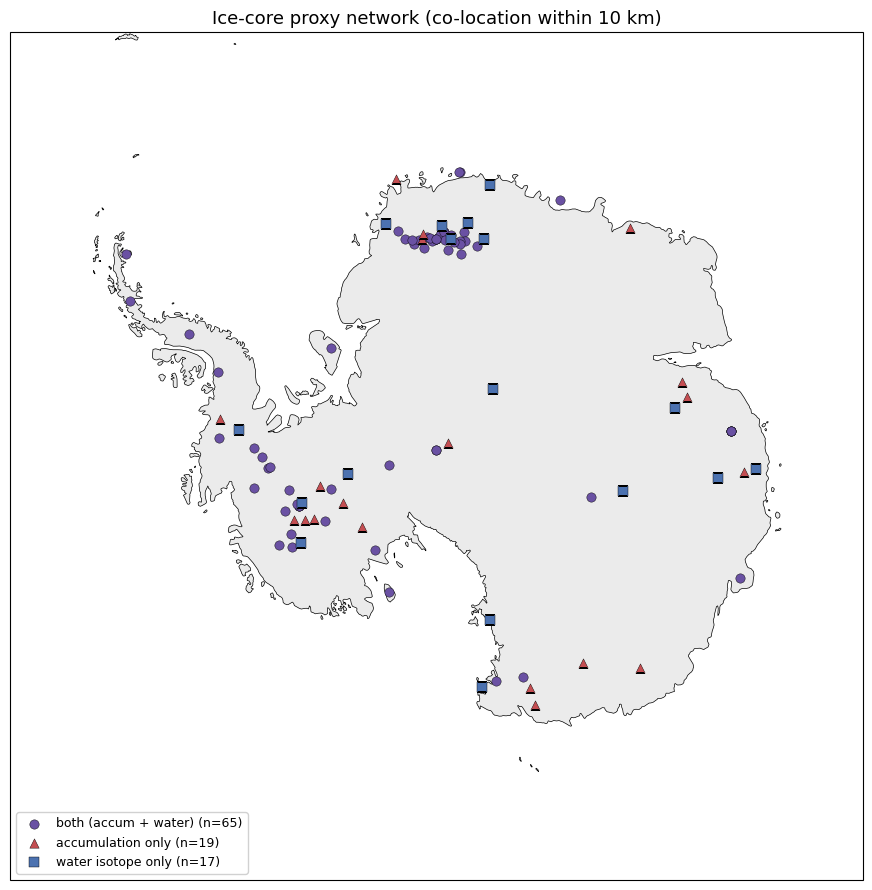

In [9]:
_xyz = lambda lat, lon: np.stack([np.cos(np.deg2rad(lat))*np.cos(np.deg2rad(lon)),
                                  np.cos(np.deg2rad(lat))*np.sin(np.deg2rad(lon)), np.sin(np.deg2rad(lat))], -1)
chord_km = lambda d: 2*np.arcsin(np.clip(d/2, 0, 1))*6371.0
MATCH_KM = 10.0
acc_xyz, wat_xyz = _xyz(core_lats, core_lons), _xyz(water_lats, water_lons)
acc_has_water = chord_km(cKDTree(wat_xyz).query(acc_xyz)[0]) < MATCH_KM
wat_has_acc   = chord_km(cKDTree(acc_xyz).query(wat_xyz)[0]) < MATCH_KM
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": ccrs.SouthPolarStereo()})
ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0); ax.add_feature(cfeature.LAND, facecolor="0.92", zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)
for lon, lat, c, mk, lbl in [
        (core_lons[acc_has_water], core_lats[acc_has_water], "#6A51A3", "o", "both (accum + water)"),
        (core_lons[~acc_has_water], core_lats[~acc_has_water], "#C44E52", "^", "accumulation only"),
        (water_lons[~wat_has_acc], water_lats[~wat_has_acc], "#4C72B0", "s", "water isotope only")]:
    ax.scatter(lon, lat, s=45, c=c, marker=mk, edgecolor="k", linewidth=0.3,
               transform=ccrs.PlateCarree(), zorder=3, label=f"{lbl} (n={len(lon)})")
ax.legend(loc="lower left", fontsize=9, framealpha=0.9)
ax.set_title(f"Ice-core proxy network (co-location within {MATCH_KM:.0f} km)", fontsize=13)
plt.tight_layout(); plt.show()


## 3 · Data assimilation — offline EnSRF

In [10]:
def run_ensrf_spatial_unc(prior_cells, y_e, R_diag_vec, proxy_data_full, n_proxy, integ):
    Ns = prior_cells.shape[1]
    post_mean = np.zeros((200, Ns), np.float32); post_std = np.zeros((200, Ns), np.float32)
    reg_ens = np.zeros((200, N_CAL, integ.shape[0]))
    for i in range(200):
        X_mean = prior_cells.mean(axis=0); X_dev = prior_cells - X_mean
        for j in range(n_proxy):
            if np.isnan(proxy_data_full[i, j]): continue
            y_mean = y_e[j, :].mean(); y_var = np.var(y_e[j, :], ddof=1)
            if not np.isfinite(y_mean) or y_var == 0: continue
            y_dev = y_e[j, :] - y_mean
            K = ((X_dev.T @ y_dev) / (N_CAL - 1)) / (y_var + R_diag_vec[j])
            X_mean = X_mean + K * (proxy_data_full[i, j] - y_mean)
            alpha = 1.0 / (1.0 + np.sqrt(R_diag_vec[j] / (y_var + R_diag_vec[j])))
            X_dev = X_dev - alpha * np.outer(y_dev, K)
        post_mean[i] = X_mean; post_std[i] = X_dev.std(axis=0, ddof=1)
        reg_ens[i] = (integ @ (X_mean[None, :] + X_dev).T).T
    return post_mean, post_std, reg_ens


In [11]:
_va = cell_area_m2.reshape(-1)[valid_cells]
_regions = {"AIS": basin_ids > 0, "WAIS": np.isin(basin_ids,[3,7,8,9,10]),
            "EAIS": np.isin(basin_ids,[1,2,11,12,13,14,15,16,17,18]), "AP": np.isin(basin_ids,[4,5,6])}
A_smb   = np.vstack([np.where(_regions[r], _va, 0) / 1e12 for r in region_names])
A_basin = np.vstack([np.where(basin_ids == b, _va, 0) / 1e12 for b in basin_ids_unique])
A_all   = np.vstack([A_smb, A_basin])

smb_cells = smb_ann.sel(year=CAL_YEARS).values.reshape(N_CAL, -1)[:, valid_cells].astype(np.float32)
print("Running SMB EnSRF (%d grounded cells) ..." % smb_cells.shape[1])
smb_post_v, smb_std_v, reg_ens_all = run_ensrf_spatial_unc(smb_cells, y_e_smb, R_smb_diag, proxy_smb, 164, A_all)

smb_reg_ens_raw   = reg_ens_all[:, :, :4]
smb_basin_ens_raw = reg_ens_all[:, :, 4:]
racmo_smb_recon_raw = np.full((200, NY*NX), np.nan, np.float32)
racmo_smb_recon_raw[:, valid_cells] = smb_post_v
racmo_smb_recon_raw = racmo_smb_recon_raw.reshape(200, NY, NX)
smb_reg_mean_raw = smb_reg_ens_raw.mean(1); smb_reg_std_raw = smb_reg_ens_raw.std(1, ddof=1)
print("Raw reconstruction ready.")



Running SMB EnSRF (10778 grounded cells) ...
Raw reconstruction ready.


## 4 · Variance correction (LTV)

In [12]:
W, FMAX, TAPER_YRS = 31, 5.0, 0        # TAPER_YRS>0 ramps the factor back to 1 over N years after the split
SPLIT_YEAR = 1956                      # <-- tweakable: correction applied THROUGH this year (inclusive)
BASE_END   = 1900                      # baseline + GGM window end — held FIXED at 1900

i_split = int(np.clip(SPLIT_YEAR - 1801 + 1, 0, 200))   # first uncorrected index
i_base  = BASE_END - 1801 + 1                            # = 100, fixed

_r = lambda x: pd.Series(np.asarray(x, float)).rolling(W, center=True, min_periods=max(4, W//2))
roll_mean = lambda x: _r(x).mean().values
roll_var  = lambda x: _r(x).var(ddof=1).values
dvar = lambda x: np.var(np.asarray(x,float)-np.polyval(np.polyfit(np.arange(len(x)),np.asarray(x,float),1),
                                                        np.arange(len(x))), ddof=1)

# --- LTV amplitude per region over the FIXED 1801-BASE_END window (feeds the null) ---
reg_var_raw = smb_reg_ens_raw.var(1, ddof=1)
sig_total_ltv = {}
for k, r in enumerate(region_names):
    v_mean = dvar(smb_reg_mean_raw[0:i_base, k]); v_post = reg_var_raw[0:i_base, k].mean()
    sig_total_ltv[r] = np.sqrt(v_mean + v_post)
    print(f"{r}: sigma_mean {np.sqrt(v_mean):6.1f}   LTV total {sig_total_ltv[r]:6.1f}   "
          f"x{sig_total_ltv[r]/np.sqrt(v_mean):.2f}")

# --- per-basin time-varying factor, applied only through SPLIT_YEAR ---
mean_b = smb_basin_ens_raw.mean(1); var_b = smb_basin_ens_raw.var(1, ddof=1)
f_b = np.ones_like(mean_b)
for b in range(mean_b.shape[1]):
    v_mean, v_post = roll_var(mean_b[:, b]), roll_mean(var_b[:, b])
    f = np.sqrt((v_mean + v_post) / np.maximum(v_mean, 1e-12))
    f_b[:, b] = np.clip(pd.Series(f).ffill().bfill().values, 1.0, FMAX)

f_use = f_b.copy()
f_use[i_split:, :] = 1.0                                   # uncorrected from SPLIT_YEAR+1 onward
if TAPER_YRS > 0:                                          # optional smooth hand-off at the split
    f_edge = f_b[max(i_split-1, 0), :]
    for j in range(TAPER_YRS):
        i = i_split + j
        if i < f_use.shape[0]:
            f_use[i, :] = 1.0 + (f_edge - 1.0) * (1.0 - (j+1)/TAPER_YRS)
print(f"split at {SPLIT_YEAR}: factor there = {f_b[max(i_split-1,0)].mean():.2f}  "
      f"(set TAPER_YRS>0 to smooth the hand-off)")

# --- build the working series: corrected mean, spread preserved; baseline fixed to 1801-BASE_END ---
base_b   = mean_b[0:i_base].mean(0)
mean_cor = base_b + (mean_b - base_b) * f_use
smb_basin_ens = mean_cor[:, None, :] + (smb_basin_ens_raw - mean_b[:, None, :])
bcol = {b: i for i, b in enumerate(basin_ids_unique)}
reg_cols = {"AIS":  [bcol[b] for b in basin_ids_unique],
            "WAIS": [bcol[b] for b in [3,7,8,9,10] if b in bcol],
            "EAIS": [bcol[b] for b in [1,2,11,12,13,14,15,16,17,18] if b in bcol],
            "AP":   [bcol[b] for b in [4,5,6] if b in bcol]}
smb_reg_ens  = np.stack([smb_basin_ens[:, :, reg_cols[r]].sum(2) for r in region_names], axis=2)
smb_reg_mean = smb_reg_ens.mean(1); smb_reg_std = smb_reg_ens.std(1, ddof=1)
ais_rac_recon, wais_rac_recon, eais_rac_recon, ap_rac_recon = (smb_reg_mean[:, k] for k in range(4))
ais_rac_std,  wais_rac_std,  eais_rac_std,  ap_rac_std      = (smb_reg_std[:, k]  for k in range(4))
smb_std_by_region = {"AIS": ais_rac_std, "WAIS": wais_rac_std, "EAIS": eais_rac_std, "AP": ap_rac_std}
recon_series = {"AIS": ais_rac_recon, "WAIS": wais_rac_recon, "EAIS": eais_rac_recon, "AP": ap_rac_recon}

bcell = np.full((NY, NX), -1, int)
for i, b in enumerate(basin_ids_unique): bcell[basin_mask == b] = i
valid2d = bcell >= 0
cellmean = np.nanmean(racmo_smb_recon_raw[:i_base], axis=0)
fcell = f_use[:, np.where(valid2d, bcell, 0)]; fcell[:, ~valid2d] = 1.0
racmo_smb_recon = cellmean[None] + (racmo_smb_recon_raw - cellmean[None]) * fcell
smb_basin_recon = basin_sums_Gt(racmo_smb_recon, recon_years)
print(f"Working series: LTV-corrected 1801-{SPLIT_YEAR}, raw {SPLIT_YEAR+1}-2000.")






AIS: sigma_mean   75.2   LTV total   95.9   x1.28
WAIS: sigma_mean   60.4   LTV total   66.9   x1.11
EAIS: sigma_mean   62.4   LTV total   81.8   x1.31
AP: sigma_mean   23.3   LTV total   28.2   x1.21
split at 1956: factor there = 1.21  (set TAPER_YRS>0 to smooth the hand-off)
Working series: LTV-corrected 1801-1956, raw 1957-2000.


/var/folders/4d/5th1wr_s21g614c74mcbh9kc0000gn/T/ipykernel_51889/3291816055.py:61: RuntimeWarning: Mean of empty slice
  cellmean = np.nanmean(racmo_smb_recon_raw[:i_base], axis=0)


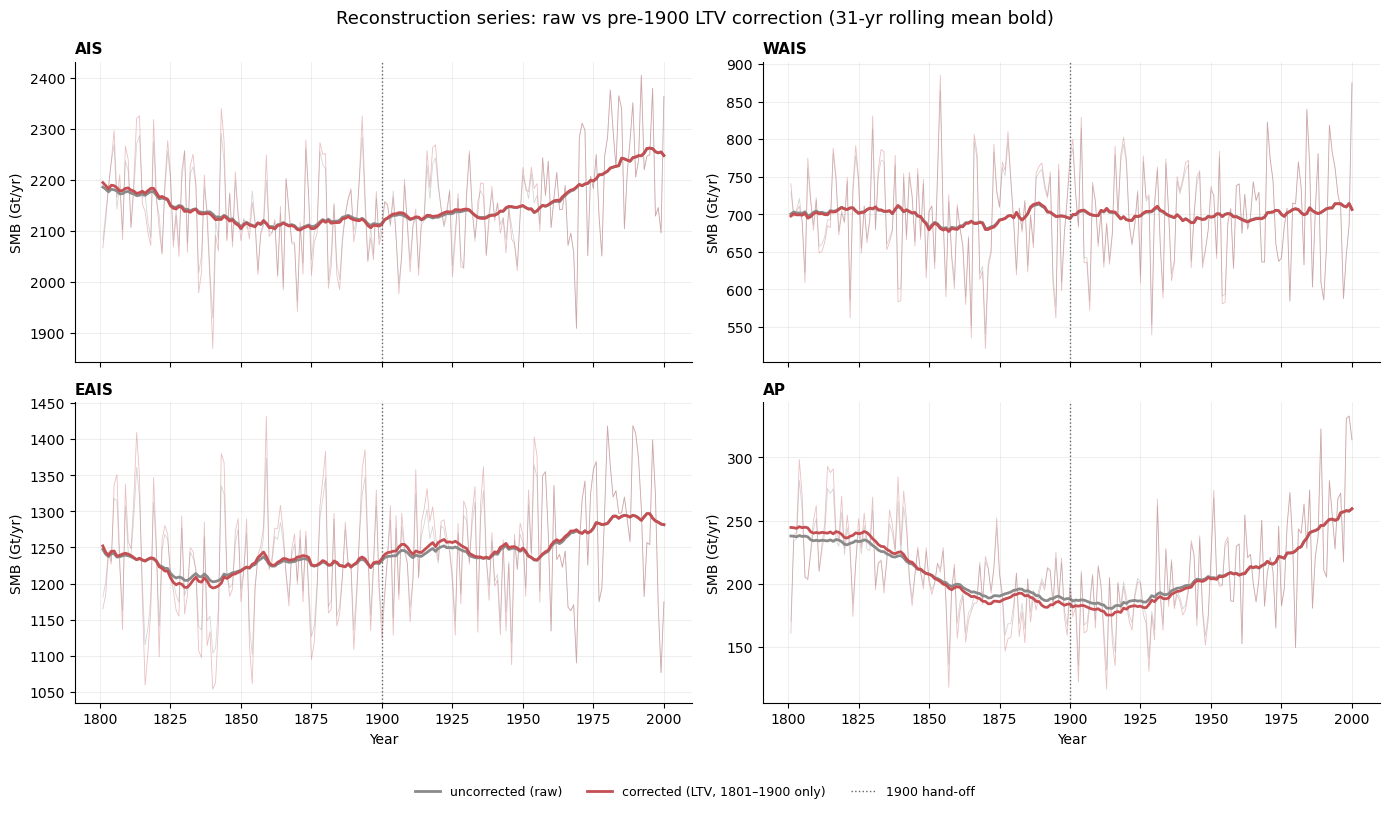

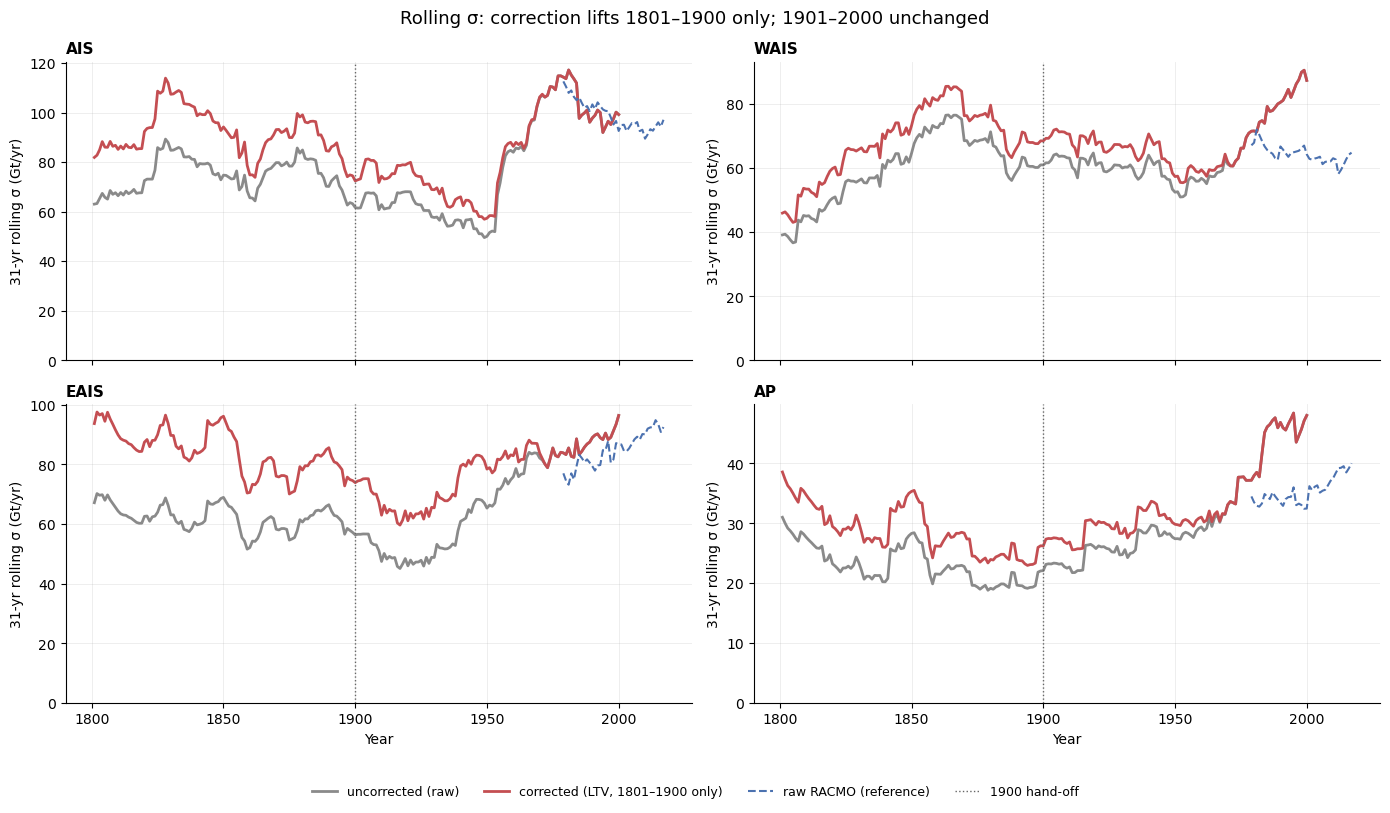

In [13]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

Wr = 31
_rr = lambda x: pd.Series(np.asarray(x, float)).rolling(Wr, center=True, min_periods=max(4, Wr//2))
r_mean = lambda x: _rr(x).mean().values
r_std  = lambda x: _rr(x).std(ddof=1).values
years_r = np.arange(1801, 1801 + smb_reg_mean.shape[0])
C_RAW, C_COR, C_REF = "#8a8a8a", "#C44E52", "#4C72B0"

# --- Figure 1: series (annual faint, 31-yr rolling mean bold) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, (k, r) in zip(axes.ravel(), enumerate(region_names)):
    ax.plot(years_r, smb_reg_mean_raw[:, k], color=C_RAW, lw=0.6, alpha=0.35)
    ax.plot(years_r, smb_reg_mean[:, k],     color=C_COR, lw=0.6, alpha=0.35)
    ax.plot(years_r, r_mean(smb_reg_mean_raw[:, k]), color=C_RAW, lw=2)
    ax.plot(years_r, r_mean(smb_reg_mean[:, k]),     color=C_COR, lw=2)
    ax.axvline(1900, color="0.4", lw=1.0, ls=":")
    ax.set_title(r, fontsize=11, fontweight="bold", loc="left")
    ax.set_ylabel("SMB (Gt/yr)"); ax.grid(alpha=0.25, lw=0.6)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
for ax in axes[-1, :]: ax.set_xlabel("Year")
fig.legend(handles=[Line2D([0],[0], color=C_RAW, lw=2, label="uncorrected (raw)"),
                    Line2D([0],[0], color=C_COR, lw=2, label="corrected (LTV, 1801–1900 only)"),
                    Line2D([0],[0], color="0.4", lw=1.0, ls=":", label="1900 hand-off")],
           loc="lower center", ncol=3, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"Reconstruction series: raw vs pre-1900 LTV correction ({Wr}-yr rolling mean bold)", fontsize=13)
fig.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

# --- Figure 2: rolling standard deviation, with the raw-RACMO reference ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, (k, r) in zip(axes.ravel(), enumerate(region_names)):
    ax.plot(years_r, r_std(smb_reg_mean_raw[:, k]), color=C_RAW, lw=2)
    ax.plot(years_r, r_std(smb_reg_mean[:, k]),     color=C_COR, lw=2)
    ry = raw_series[r].index.values
    ax.plot(ry, _rr(raw_series[r].values).std(ddof=1).values, color=C_REF, lw=1.5, ls="--")
    ax.axvline(1900, color="0.4", lw=1.0, ls=":")
    ax.set_title(r, fontsize=11, fontweight="bold", loc="left")
    ax.set_ylabel(f"{Wr}-yr rolling σ (Gt/yr)"); ax.set_ylim(bottom=0)
    ax.grid(alpha=0.25, lw=0.6)
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
for ax in axes[-1, :]: ax.set_xlabel("Year")
fig.legend(handles=[Line2D([0],[0], color=C_RAW, lw=2, label="uncorrected (raw)"),
                    Line2D([0],[0], color=C_COR, lw=2, label="corrected (LTV, 1801–1900 only)"),
                    Line2D([0],[0], color=C_REF, lw=1.5, ls="--", label="raw RACMO (reference)"),
                    Line2D([0],[0], color="0.4", lw=1.0, ls=":", label="1900 hand-off")],
           loc="lower center", ncol=4, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Rolling σ: correction lifts 1801–1900 only; 1901–2000 unchanged", fontsize=13)
fig.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()


## 5 · Reconstructed SMB — series and trends

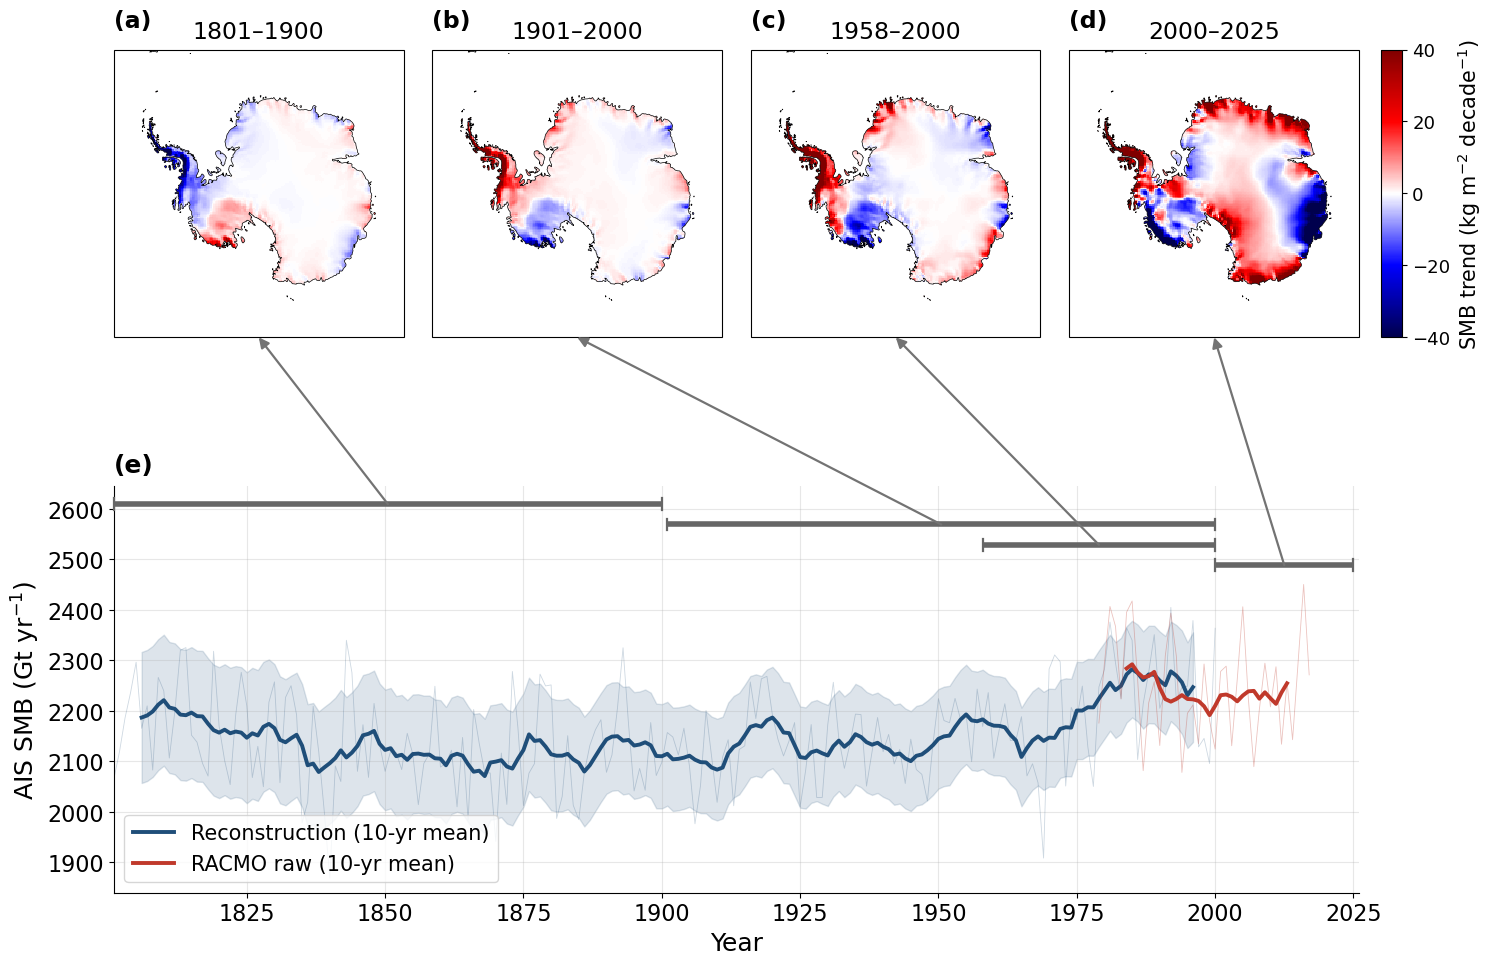

In [14]:
# ===== Stacked figure: AIS SMB time series + spatial-trend maps (true 10-yr mean, vertical cbar, arrows) =====
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs, cartopy.feature as cfeature
from matplotlib.transforms import blended_transform_factory
from matplotlib.patches import ConnectionPatch

def spatial_trend(cube, y0, y1, off):
    sub = cube[y0-off:y1-off+1]
    t = np.arange(sub.shape[0], dtype=float); X = np.vstack([t, np.ones_like(t)]).T
    beta, *_ = np.linalg.lstsq(X, sub.reshape(sub.shape[0], -1), rcond=None)
    return beta[0].reshape(sub.shape[1], sub.shape[2]) * 10
roll = lambda s, w=10: pd.Series(np.asarray(s, float)).rolling(w, center=True, min_periods=w).mean().values  # true 10-yr

# panel (c): reconstruction 1958–1978  +  raw RACMO 1979–2000
cube_c = np.concatenate([racmo_smb_recon[1958-1801:1979-1801],     # 1958–1978 (recon)
                         smb_ann.values[1979-1979:2000-1979+1]],   # 1979–2000 (RACMO)
                        axis=0)

C_REC, C_RAC = "#1f4e79", "#c0392b"; CMAP = "seismic"
periods = [("(a)", "1801–1900", racmo_smb_recon, 1801, 1900, 1801),
           ("(b)", "1901–2000", racmo_smb_recon, 1901, 2000, 1801),
           ("(c)", "1958–2000", cube_c,          1958, 2000, 1958),   # hybrid recon+RACMO
           ("(d)", "2000–2025", smb_ann.values,  2000, 2025, 1979)]

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 4, height_ratios=[1.0, 1.35], hspace=0.40, wspace=0.10,
                       left=0.07, right=0.90, top=0.94, bottom=0.09)
map_axes = []
for j, (letter, yrs, cube, y0, y1, off) in enumerate(periods):
    axm = fig.add_subplot(gs[0, j], projection=ccrs.SouthPolarStereo()); map_axes.append(axm)
    axm.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    im = axm.pcolormesh(lon_racmo, lat_racmo, spatial_trend(cube, y0, y1, off),
                        transform=ccrs.PlateCarree(), vmin=-40, vmax=40, cmap=CMAP, zorder=1)
    axm.add_feature(cfeature.OCEAN, facecolor="white", zorder=2)
    axm.add_feature(cfeature.COASTLINE, lw=0.5, zorder=3)
    axm.set_title(yrs, fontsize=17, pad=8, color="black")
    axm.text(0.0, 1.06, letter, transform=axm.transAxes, ha="left", va="bottom",
             fontsize=17, fontweight="bold", color="black")

p0 = map_axes[0].get_position(); p3 = map_axes[3].get_position()
cax = fig.add_axes([p3.x1 + 0.015, p3.y0, 0.014, p3.height])
cb = fig.colorbar(im, cax=cax, orientation="vertical")
cb.set_label("SMB trend (kg m$^{-2}$ decade$^{-1}$)", fontsize=15); cb.ax.tick_params(labelsize=13)

axt = fig.add_subplot(gs[1, :])
std = 2*smb_reg_std[:, 0]
axt.plot(recon_years, recon_series["AIS"], color=C_REC, lw=0.6, alpha=0.22)
axt.fill_between(recon_years, roll(recon_series["AIS"]-std), roll(recon_series["AIS"]+std), color=C_REC, alpha=0.15)
axt.plot(recon_years, roll(recon_series["AIS"]), color=C_REC, lw=2.8, label="Reconstruction (10-yr mean)")
axt.plot(raw_series["AIS"].index, raw_series["AIS"].values, color=C_RAC, lw=0.6, alpha=0.30)
axt.plot(raw_series["AIS"].index, roll(raw_series["AIS"].values), color=C_RAC, lw=2.8, label="RACMO raw (10-yr mean)")
axt.set_xlim(1801, 2026); axt.set_xlabel("Year", fontsize=18)
axt.set_ylabel("AIS SMB (Gt yr$^{-1}$)", fontsize=18)
axt.tick_params(labelsize=16); axt.grid(alpha=0.3); axt.legend(fontsize=15, loc="lower left")
for sp in ("top", "right"): axt.spines[sp].set_visible(False)
axt.text(0.0, 1.02, "(e)", transform=axt.transAxes, fontsize=18, fontweight="bold", va="bottom")

# --- neutral period bars + arrows linking each span to its map ---
_lo, _hi = axt.get_ylim(); axt.set_ylim(_lo, _hi + 0.26*(_hi-_lo))
trans = blended_transform_factory(axt.transData, axt.transAxes)
for (letter, _yrs, _cube, y0, y1, _off), axm, yl in zip(periods, map_axes, [0.955, 0.905, 0.855, 0.805]):
    axt.plot([y0, y1], [yl, yl], color="0.4", lw=4, solid_capstyle="butt", transform=trans, clip_on=False, zorder=6)
    for xx in (y0, y1):
        axt.plot([xx, xx], [yl-0.014, yl+0.014], color="0.4", lw=1.6, transform=trans, clip_on=False, zorder=6)
    con = ConnectionPatch(xyA=(0.5*(y0+y1), yl), coordsA=trans, xyB=(0.5, 0.0), coordsB=axm.transAxes,
                          arrowstyle="-|>", color="0.45", lw=1.6, mutation_scale=15, zorder=10)
    fig.add_artist(con)
plt.show()


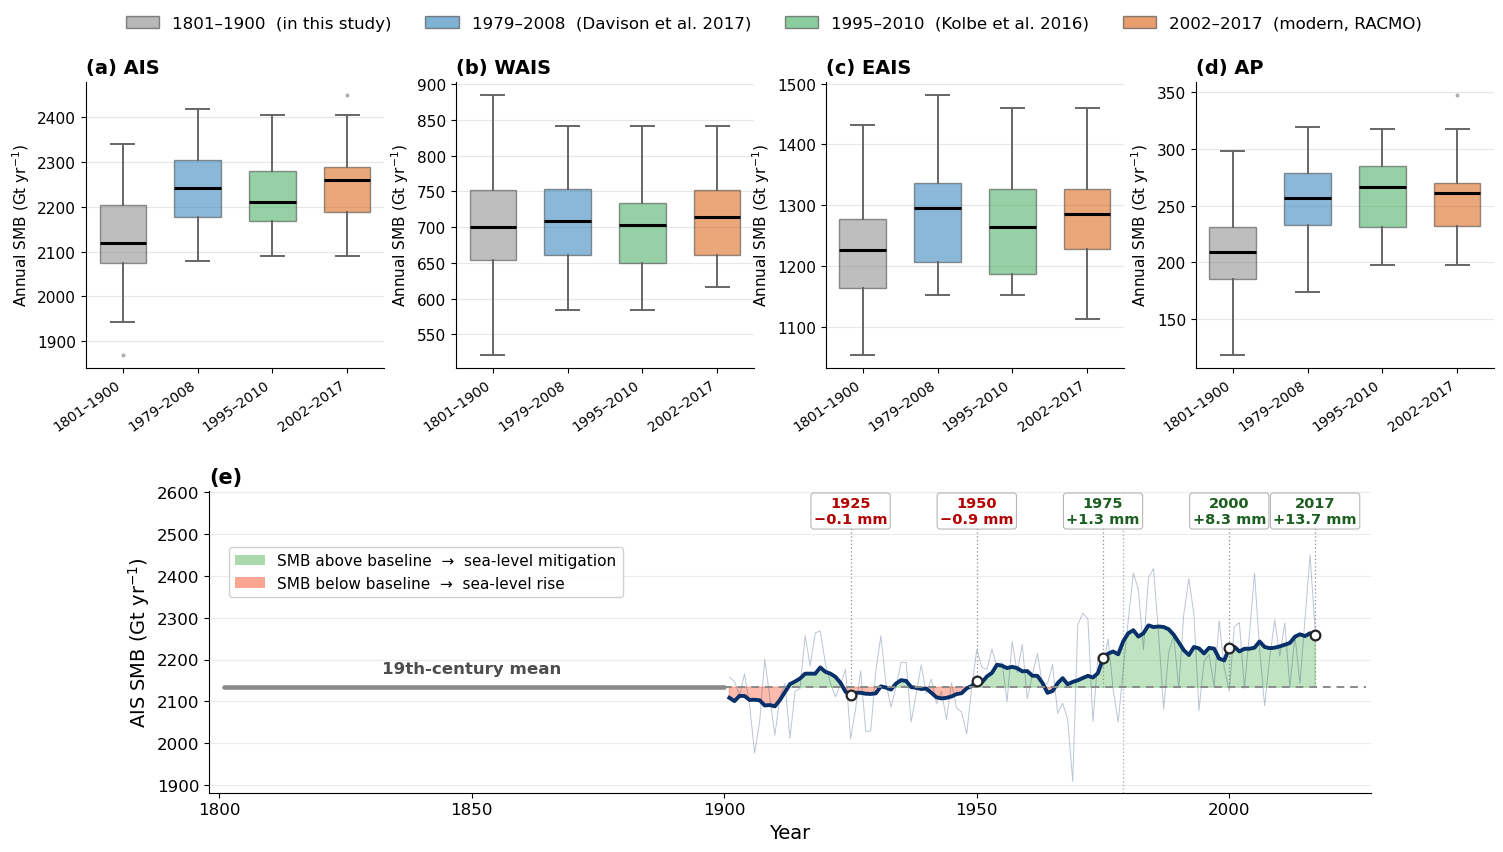

In [15]:
# ===== Regional boxplots (with study key) + AIS SMB 1901–2017 with 25-yr mitigation checkpoints =====
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
GT = 361.8

def region_vals(r, y0, y1, src):
    s = pd.Series(recon_series[r], index=recon_years) if src == "recon" else raw_series[r]
    return s.loc[y0:y1].values

periods4 = [("1801–1900", 1801, 1900, "recon"), ("1979–2008", 1979, 2008, "raw"),
            ("1995–2010", 1995, 2010, "raw"), ("2002–2017", 2002, 2017, "raw")]
PLAB4 = [p[0] for p in periods4]
PCOL4 = ["#8a8a8a", "#2C7FB8", "#41ab5d", "#D95F0E"]
STUDY = ["1801–1900  (in this study)", "1979–2008  (Davison et al. 2017)",
         "1995–2010  (Kolbe et al. 2016)", "2002–2017  (modern, RACMO)"]

fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 12, height_ratios=[0.95, 1.0], hspace=0.42, wspace=1.4,
                       left=0.07, right=0.95, top=0.88, bottom=0.09)
fig.legend(handles=[Patch(facecolor=PCOL4[i], alpha=0.6, edgecolor="0.25", label=STUDY[i]) for i in range(4)],
           loc="upper center", ncol=4, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 0.97))

# --- row 0: regional boxplots (a)-(d) ---
for j, r in enumerate(region_names):
    axb = fig.add_subplot(gs[0, 3*j:3*j+3])
    data = [region_vals(r, y0, y1, src) for (_, y0, y1, src) in periods4]
    bp = axb.boxplot(data, positions=range(4), widths=0.62, patch_artist=True, manage_ticks=False,
                     medianprops=dict(color="black", lw=2.2), whiskerprops=dict(color="0.4", lw=1.4),
                     capprops=dict(color="0.4", lw=1.4), flierprops=dict(marker=".", ms=4, mfc="0.4", mec="0.4", alpha=0.4))
    for patch, c in zip(bp["boxes"], PCOL4):
        patch.set_facecolor(c); patch.set_alpha(0.55); patch.set_edgecolor("0.25")
    axb.set_xticks(range(4)); axb.set_xticklabels(PLAB4, rotation=35, ha="right", fontsize=10)
    axb.set_title(f"({chr(97+j)}) {r}", fontsize=14, fontweight="bold", loc="left")
    axb.set_ylabel("Annual SMB (Gt yr$^{-1}$)", fontsize=11)
    axb.tick_params(axis="y", labelsize=11); axb.grid(axis="y", alpha=0.3); axb.set_axisbelow(True)
    for sp in ("top", "right"): axb.spines[sp].set_visible(False)

# --- row 1 (e): AIS SMB 1901–2017, area = mitigation, with 25-yr checkpoints ---
axz = fig.add_subplot(gs[1, 1:11])
ais = pd.Series(recon_series["AIS"], index=recon_years); base = ais.loc[1801:1900].mean()
ts = pd.concat([ais.loc[1901:1978], raw_series["AIS"].loc[1979:2017]])
roll = lambda s: pd.Series(np.asarray(s, float)).rolling(11, center=True, min_periods=6).mean().values
rollv = roll(ts.values); C_TS, C_POS, C_NEG = "#08306b", "#74c476", "#fb6a4a"

axz.fill_between(ts.index, base, rollv, where=(rollv >= base), color=C_POS, alpha=0.45, interpolate=True, zorder=1)
axz.fill_between(ts.index, base, rollv, where=(rollv <  base), color=C_NEG, alpha=0.45, interpolate=True, zorder=1)
axz.plot([1801, 1900], [base, base], color=PCOL4[0], lw=3.3, solid_capstyle="round", zorder=4)
axz.plot([1900, 2027], [base, base], color=PCOL4[0], lw=1.4, ls=(0, (4, 3)), zorder=4)
axz.annotate("19th-century mean", (1850, base), textcoords="offset points", xytext=(0, 8),
             ha="center", va="bottom", fontsize=12, fontweight="bold", color="0.3")
axz.plot(ts.index, ts.values, color=C_TS, lw=0.7, alpha=0.28, zorder=2)
axz.plot(ts.index, rollv, color=C_TS, lw=2.8, zorder=3)
axz.axvline(1979, color="0.7", lw=1.0, ls=":", zorder=1)

allv = np.concatenate([ts.values, [base]]); span = np.ptp(allv)
lo_y, hi_y = allv.min() - 0.05*span, allv.max() + 0.28*span
axz.set_xlim(1798, 2028); axz.set_ylim(lo_y, hi_y)
y_lab = hi_y - 0.02*span
for cy in [1925, 1950, 1975, 2000, 2017]:
    cum = (ts.loc[1901:cy] - base).sum() / GT
    yc = np.interp(cy, ts.index, rollv)
    axz.plot([cy, cy], [base, y_lab - 0.10*span], color="0.55", lw=0.9, ls=(0, (1, 2)), zorder=3)
    axz.plot(cy, yc, "o", ms=7, mfc="white", mec="0.15", mew=1.6, zorder=5)
    axz.annotate(f"{cy}\n{'+' if cum >= 0 else '−'}{abs(cum):.1f} mm", (cy, y_lab), ha="center", va="top",
                 fontsize=10.5, fontweight="bold", color=("#1b5e20" if cum >= 0 else "#b30000"),
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.7", lw=0.8, alpha=0.95))
axz.set_xlabel("Year", fontsize=14); axz.set_ylabel("AIS SMB (Gt yr$^{-1}$)", fontsize=14)
axz.tick_params(labelsize=12); axz.grid(axis="y", alpha=0.25); axz.set_axisbelow(True)
for sp in ("top", "right"): axz.spines[sp].set_visible(False)
axz.legend(handles=[Patch(facecolor=C_POS, alpha=0.6, label="SMB above baseline  →  sea-level mitigation"),
                    Patch(facecolor=C_NEG, alpha=0.6, label="SMB below baseline  →  sea-level rise")],
           fontsize=11, loc="upper left", bbox_to_anchor=(0.01, 0.84), framealpha=0.9)
axz.set_title("(e)", fontsize=15, fontweight="bold", loc="left")
plt.show()


## 6 · Natural variability and emergence (GGM null)

In [16]:
def _ggm_psi(kappa, phi, K):
    d = 0.5*kappa; a = 1.0-phi; psi = np.empty(K); psi[0] = 1.0
    for k in range(1, K): psi[k] = psi[k-1]*(d+k-1.0)/k*a
    return psi
def _ggm_acf(kappa, phi, n, K=None):
    if K is None: K = int(min(20000, max(2000, 30*n if phi > 0.02 else 20000)))
    psi = _ggm_psi(kappa, phi, K+n)
    return np.array([np.dot(psi[:K], psi[h:h+K]) for h in range(n)])
def _toeplitz(r):
    n = len(r); idx = np.abs(np.arange(n)[:, None] - np.arange(n)[None, :]); return r[idx]
def ggm_fit(x, kappa0=1.0, phi0=0.1, bounds=((0.0,4.0),(1e-4,1.0))):
    from scipy.optimize import minimize
    x = np.asarray(x, float); x = x - x.mean(); n = len(x)
    def negll(th):
        r = _ggm_acf(th[0], th[1], n)
        try: L = np.linalg.cholesky(_toeplitz(r))
        except np.linalg.LinAlgError: return 1e12
        z = np.linalg.solve(L, x); s2 = (z@z)/n
        return 0.5*(n*np.log(2*np.pi*s2) + 2.0*np.log(np.diag(L)).sum() + n)
    res = minimize(negll, [kappa0, phi0], method="L-BFGS-B", bounds=bounds)
    r = _ggm_acf(*res.x, n); L = np.linalg.cholesky(_toeplitz(r)); z = np.linalg.solve(L, x)
    return dict(kappa=res.x[0], phi=res.x[1], sigma_w=np.sqrt((z@z)/n))

ggm_fits = {}
for k, r in enumerate(region_names):
    f_raw = ggm_fit(smb_reg_mean_raw[0:100, k])                    # SHAPE from RAW mean (old)
    f     = ggm_fit(smb_reg_mean[0:100, k])                        # SHAPE from VARIANCE-CORRECTED mean (new)
    marg = np.sqrt(_ggm_acf(f["kappa"], f["phi"], 1)[0]) * f["sigma_w"]
    f["sigma_w"] *= sig_total_ltv[r] / marg                        # AMPLITUDE from LTV (unchanged)
    ggm_fits[r] = f
    print(f"{r}: kappa {f['kappa']:.2f} (raw was {f_raw['kappa']:.2f})  phi {f['phi']:.3f}  "
          f"sigma_w {f['sigma_w']:.1f}  (= LTV {sig_total_ltv[r]:.1f})")





AIS: kappa 0.00 (raw was 0.00)  phi 1.000  sigma_w 95.9  (= LTV 95.9)
WAIS: kappa 0.00 (raw was 0.00)  phi 1.000  sigma_w 66.9  (= LTV 66.9)
EAIS: kappa 4.00 (raw was 4.00)  phi 0.790  sigma_w 74.8  (= LTV 81.8)
AP: kappa 0.82 (raw was 0.82)  phi 0.019  sigma_w 23.0  (= LTV 28.2)


In [17]:
# ===== GGM refit: multi-start, with a forced-red diagnostic vs the degenerate white fit =====
from scipy.optimize import minimize
def _negll(th, x, n):
    r = _ggm_acf(th[0], th[1], n)
    try: L = np.linalg.cholesky(_toeplitz(r))
    except np.linalg.LinAlgError: return 1e12
    z = np.linalg.solve(L, x); s2 = (z@z)/n
    return 0.5*(n*np.log(2*np.pi*s2) + 2*np.log(np.diag(L)).sum() + n)
def fit_ggm(x, red=False):
    x = np.asarray(x, float); x = x - x.mean(); n = len(x)
    lo_k, hi_p = (0.05, 0.95) if red else (1e-3, 1.0)                 # 'red' path forbids the white corner
    starts = [(1.0,0.1),(0.6,0.05),(2.0,0.02),(0.3,0.3),(1.5,0.5),(0.8,0.02),(0.4,0.1)]
    best = None
    for k0, p0 in starts:
        res = minimize(_negll, [max(k0,lo_k), min(p0,hi_p)], args=(x,n),
                       method="L-BFGS-B", bounds=((lo_k,4.0),(1e-4,hi_p)))
        if best is None or res.fun < best.fun: best = res
    r = _ggm_acf(*best.x, n); L = np.linalg.cholesky(_toeplitz(r)); z = np.linalg.solve(L, x)
    return dict(kappa=best.x[0], phi=best.x[1], sigma_w=np.sqrt((z@z)/n), negll=best.fun)

print(f"{'region':<6}{'free κ':>8}{'free φ':>8}{'nLL':>9}{'red κ':>8}{'red φ':>8}{'nLL':>9}{'ΔnLL':>7}   ACF1 emp/red")
ggm_fits_red = {}
for r in region_names:
    x = np.asarray(recon_series[r])[:100]
    ff = fit_ggm(x, red=False)                                        # free multi-start (may still be white)
    fr = fit_ggm(x, red=True)                                         # forced non-degenerate
    ar = _ggm_acf(fr['kappa'], fr['phi'], 2); acf1_red = ar[1]/ar[0]
    sd = x - np.polyval(np.polyfit(np.arange(100), x, 1), np.arange(100))
    acf1_emp = np.corrcoef(sd[:-1], sd[1:])[0, 1]
    marg = np.sqrt(_ggm_acf(fr['kappa'], fr['phi'], 1)[0]) * fr['sigma_w']
    fr['sigma_w'] *= sig_total_ltv[r] / marg                          # keep LTV amplitude (isolate persistence effect)
    ggm_fits_red[r] = fr
    print(f"{r:<6}{ff['kappa']:>8.2f}{ff['phi']:>8.3f}{ff['negll']:>9.2f}"
          f"{fr['kappa']:>8.2f}{fr['phi']:>8.3f}{fr['negll']:>9.2f}{fr['negll']-ff['negll']:>7.2f}   {acf1_emp:>5.2f}/{acf1_red:.2f}")


region  free κ  free φ      nLL   red κ   red φ      nLL   ΔnLL   ACF1 emp/red
AIS       4.00   0.877   593.89    4.00   0.877   593.89   0.00    0.18/0.24
WAIS      4.00   0.957   564.12    3.49   0.950   564.12   0.00    0.08/0.09
EAIS      4.00   0.790   577.78    4.00   0.790   577.78   0.00    0.35/0.40
AP        0.82   0.019   477.25    0.82   0.019   477.25   0.00    0.32/0.54


In [18]:
# ===== variance-matched GGM nulls (marginal σ = reconstruction's 1801–1900 σ) =====
def _vm(r):
    fit = dict(ggm_fits_red[r])
    imp = np.sqrt(_ggm_acf(fit["kappa"], fit["phi"], 1)[0] * fit["sigma_w"]**2)
    emp = pd.Series(recon_series[r], index=recon_years).loc[1801:1900].std()
    fit["sigma_w"] *= emp / imp
    return fit
ggm_fits_vm = {r: _vm(r) for r in region_names}
print("variance-matched σ_w:", {r: round(ggm_fits_vm[r]["sigma_w"], 1) for r in region_names})


variance-matched σ_w: {'AIS': np.float64(92.2), 'WAIS': np.float64(68.5), 'EAIS': np.float64(77.6), 'AP': np.float64(29.5)}


region emergence
AIS         2004
WAIS        None
EAIS        2009
AP          None


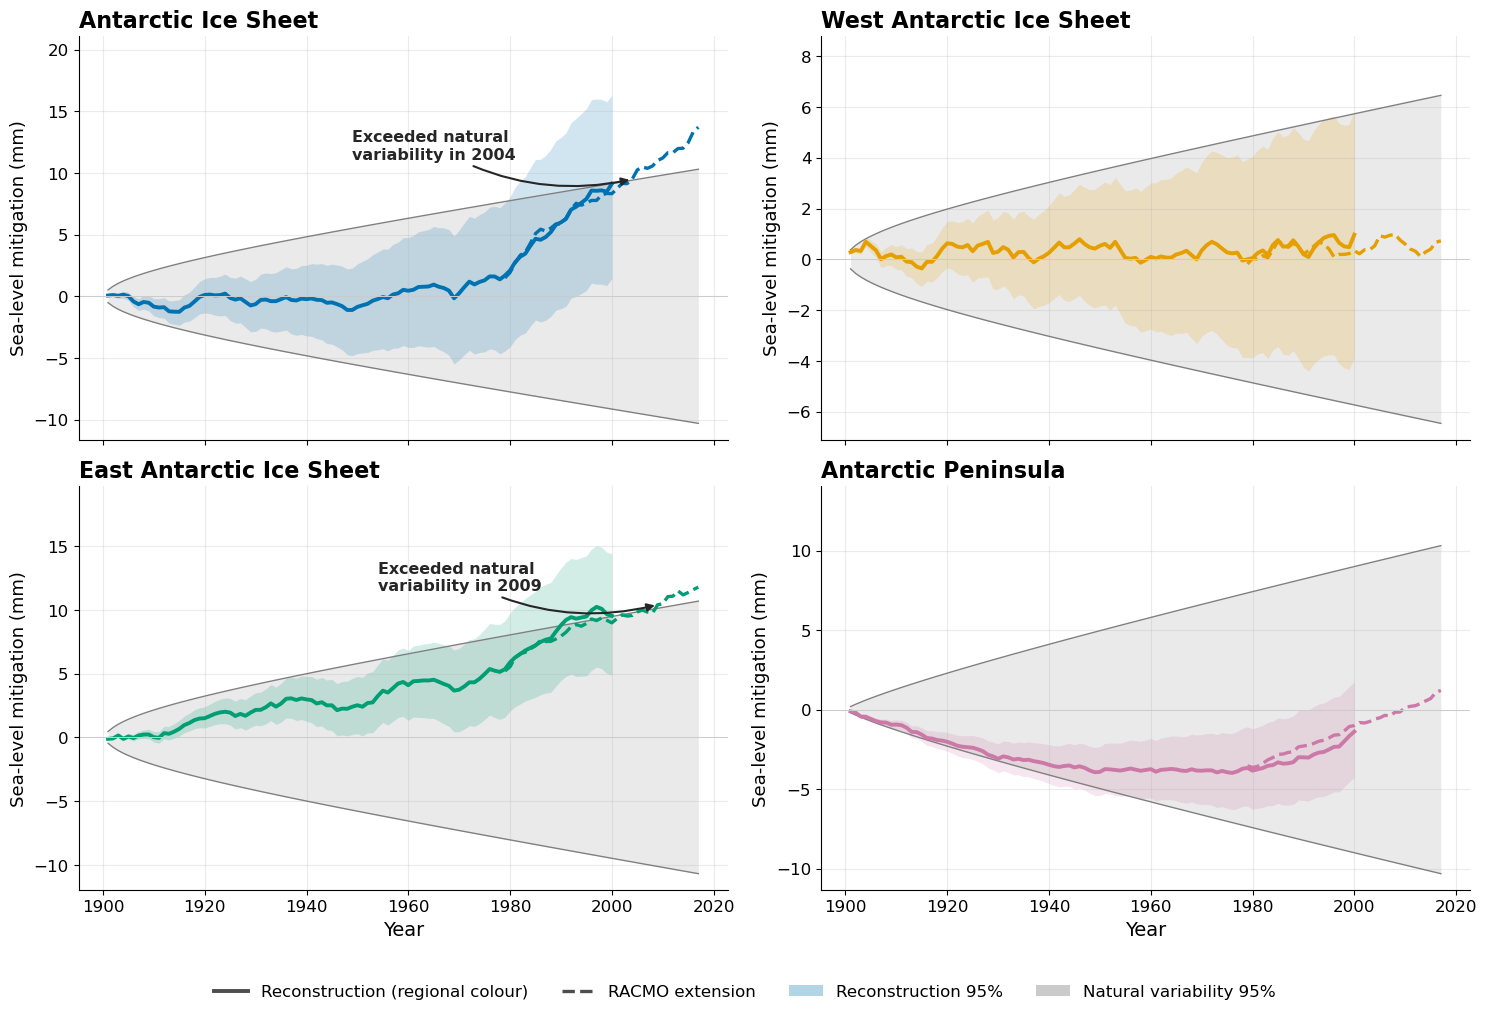

In [19]:
# ===== Figure 3: sea-level mitigation vs GGM natural-variability null (variance-matched) =====
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
GT = 361.8; NB, NA = 100, 117
CB = {"AIS":"#0072B2","WAIS":"#E69F00","EAIS":"#009E73","AP":"#CC79A7"}
FULL = {"AIS":"Antarctic Ice Sheet","WAIS":"West Antarctic Ice Sheet",
        "EAIS":"East Antarctic Ice Sheet","AP":"Antarctic Peninsula"}
region_idx = {"AIS":0,"WAIS":1,"EAIS":2,"AP":3}
def sea_level_mitigation(ts, b=slice(0,100)):
    ts = np.asarray(ts, float); return np.cumsum(ts - ts[b].mean())/GT
def extend_slm(recon_ts, obs_ts, b=slice(0,100)):
    r = np.asarray(recon_ts, float); base = r[b].mean(); return np.sum(r[:178]-base)/GT + np.cumsum((np.asarray(obs_ts)-base)/GT)
def slm_sigma(fit):
    R = _toeplitz(_ggm_acf(fit["kappa"], fit["phi"], NB+NA) * fit["sigma_w"]**2)
    return np.array([np.sqrt((a:=np.concatenate([np.full(NB,-n/NB),np.ones(n)])) @ R[:NB+n,:NB+n] @ a)/GT for n in range(1,NA+1)])
def emergence(traj, sig, years, minsus=8):
    out = traj > 1.96*sig
    for i in range(len(years)):
        if out[i:].all():
            return int(years[i]) if (len(years)-i >= minsus and years[i] <= 2017-minsus) else None
    return None

GGM = ggm_fits_vm                                       # variance-matched null
years, cent, yr_obs = np.arange(1901,2018), np.arange(1901,2001), np.arange(1979,2018)
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
print(f"{'region':<6}{'emergence':>10}")
for ax, r in zip(axes.ravel(), region_names):
    k = region_idx[r]; col = CB[r]
    recon_ts = np.asarray(recon_series[r]); obs_ts = raw_series[r].loc[1979:2017].values
    slm_recon = sea_level_mitigation(recon_ts); slm_ext = extend_slm(recon_ts, obs_ts)
    traj = np.concatenate([slm_recon[100:178], slm_ext]); sig = slm_sigma(GGM[r])
    slm_mem = np.stack([sea_level_mitigation(smb_reg_ens[:, m, k]) for m in range(smb_reg_ens.shape[1])])
    lo, hi = np.percentile(slm_mem, [2.5, 97.5], axis=0)
    cy = emergence(traj, sig, years); print(f"{r:<6}{str(cy):>10}")

    ax.fill_between(years, -1.96*sig, 1.96*sig, color="0.6", alpha=0.20, lw=0)
    ax.plot(years, 1.96*sig, color="0.5", lw=1.0); ax.plot(years, -1.96*sig, color="0.5", lw=1.0)
    ax.fill_between(cent, lo[100:200], hi[100:200], color=col, alpha=0.18, lw=0)
    ax.plot(cent, slm_recon[100:200], color=col, lw=2.8)
    ax.plot(yr_obs, slm_ext, color=col, lw=2.4, ls="--")
    ax.axhline(0, color="0.8", lw=0.7)
    if cy is not None:
        yv = traj[cy-1901]
        ax.annotate(f"Exceeded natural\nvariability in {cy}", xy=(cy, yv), xytext=(cy-55, yv+0.18*np.ptp(traj)),
                    fontsize=11.5, fontweight="bold", color="0.15", ha="left", va="center",
                    arrowprops=dict(arrowstyle="-|>", color="0.15", lw=1.5, connectionstyle="arc3,rad=0.2"))
    ax.set_title(FULL[r], fontsize=16, fontweight="bold", loc="left")
    ax.set_ylabel("Sea-level mitigation (mm)", fontsize=13); ax.tick_params(labelsize=12); ax.grid(alpha=0.25)
    lo_, hi_ = ax.get_ylim(); ax.set_ylim(lo_, hi_ + 0.12*(hi_-lo_))
    for sp in ("top","right"): ax.spines[sp].set_visible(False)
for ax in axes[-1, :]: ax.set_xlabel("Year", fontsize=14)
handles = [Line2D([0],[0], color="0.3", lw=2.8, label="Reconstruction (regional colour)"),
           Line2D([0],[0], color="0.3", lw=2.4, ls="--", label="RACMO extension"),
           Patch(facecolor=CB["AIS"], alpha=0.3, label="Reconstruction 95%"),
           Patch(facecolor="0.6", alpha=0.5, label="Natural variability 95%")]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False, fontsize=12, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()


In [20]:
# ===== Does variance-matching the null change emergence? (all regions) =====
GT=361.8; NB,NA=100,117
def sea_level_mitigation(ts,b=slice(0,100)):
    ts=np.asarray(ts,float); return np.cumsum(ts-ts[b].mean())/GT
def extend_slm(recon_ts,obs_ts,b=slice(0,100)):
    r=np.asarray(recon_ts,float); base=r[b].mean(); return np.sum(r[:178]-base)/GT+np.cumsum((np.asarray(obs_ts)-base)/GT)
def slm_sigma(fit):
    R=_toeplitz(_ggm_acf(fit["kappa"],fit["phi"],NB+NA)*fit["sigma_w"]**2)
    return np.array([np.sqrt((a:=np.concatenate([np.full(NB,-n/NB),np.ones(n)]))@R[:NB+n,:NB+n]@a)/GT for n in range(1,NA+1)])
def emg(traj,sig,years,minsus=8):
    out=traj>1.96*sig
    for i in range(len(years)):
        if out[i:].all() and (len(years)-i)>=minsus and years[i]<=2017-minsus: return int(years[i])
    return None

years=np.arange(1901,2018)
print(f"{'region':<6}{'GGM σ':>8}{'emp σ':>8}{'ratio':>7}{'emerg orig':>12}{'emerg matched':>15}")
for r in region_names:
    fit=dict(ggm_fits_red[r])
    imp=np.sqrt(_ggm_acf(fit["kappa"],fit["phi"],1)[0]*fit["sigma_w"]**2)
    emp=pd.Series(recon_series[r],index=recon_years).loc[1801:1900].std()
    fit_v=dict(fit); fit_v["sigma_w"]=fit["sigma_w"]*emp/imp
    recon_ts=np.asarray(recon_series[r]); obs_ts=raw_series[r].loc[1979:2017].values
    traj=np.concatenate([sea_level_mitigation(recon_ts)[100:178], extend_slm(recon_ts,obs_ts)])
    e0,e1=emg(traj,slm_sigma(fit),years),emg(traj,slm_sigma(fit_v),years)
    print(f"{r:<6}{imp:>8.1f}{emp:>8.1f}{emp/imp:>7.2f}{str(e0):>12}{str(e1):>15}")


region   GGM σ   emp σ  ratio  emerg orig  emerg matched
AIS       95.9    95.0   0.99        2005           2004
WAIS      66.9    68.8   1.03        None           None
EAIS      81.8    84.9   1.04        2001           2009
AP        28.2    36.1   1.28        None           None


## 7 · Attribution — SAM and (RACMO-standin) temperature

In [21]:
# ===== SAM/temperature attribution — setup: Gong–Wang (20CRv3) β + Marshall trend, per-cell sensitivities =====
import os, urllib.request
# --- Marshall (2003) station SAM: used for the long-term (1958–2000) trend ---
sam_path = os.path.expanduser("~/DataFiles/marshall_sam.txt")
if not os.path.exists(sam_path):
    urllib.request.urlretrieve("http://www.nerc-bas.ac.uk/public/icd/gjma/newsam.1957.2007.txt", sam_path)
_raw = pd.read_csv(sam_path, sep=r"\s+", header=0, index_col=0)
sam_marshall = _raw.apply(pd.to_numeric, errors="coerce").dropna().mean(axis=1); sam_marshall.index = sam_marshall.index.astype(int)

# --- Gong & Wang (1999) reanalysis SAM from 20CRv3 (SLP 40°S−65°S, standardized): used for β ---
gw_path = os.path.expanduser("~/DataFiles/sam.20crv3.long.data")
if not os.path.exists(gw_path):
    urllib.request.urlretrieve("https://psl.noaa.gov/data/20thC_Rean/timeseries/monthly/SAM/sam.20crv3.long.data", gw_path)
rows = []
with open(gw_path) as f:
    y0, y1 = (int(x) for x in f.readline().split())
    for line in f:
        p = line.split()
        if len(p) != 13 or not p[0].lstrip("-").isdigit(): break
        yr = int(p[0])
        if yr < y0 or yr > y1: break
        v = np.array([float(x) for x in p[1:]]); v[v <= -90] = np.nan
        rows.append((yr, np.nanmean(v)))
sam_gw_raw = pd.Series(dict(rows))

# --- standardize BOTH annual indices to unit variance over a common window → consistent "per 1σ" units ---
def zscore(s, ref=slice(1979, 2000)):
    r = s.loc[ref]; return (s - r.mean()) / r.std(ddof=1)
sam = zscore(sam_marshall)        # standardized Marshall → drives the 1958–2000 trend (downstream cells)
sam_gw = zscore(sam_gw_raw)       # standardized Gong–Wang → drives the sensitivity β

def detrend_cols(A):
    t = np.arange(A.shape[0], dtype=float); tc = t - t.mean()
    return A - A.mean(0) - tc[:, None] * ((tc[:, None]*A).sum(0)/(tc@tc))[None, :]
def trend_cols(A):
    t = np.arange(A.shape[0], dtype=float); tc = t - t.mean()
    return (tc[:, None] * A).sum(0) / (tc @ tc)
def _cols(da, y0, y1, scale=1.0):
    return da.sel(year=slice(y0, y1)).values.reshape(y1-y0+1, -1)[:, valid_cells] * scale
def paint_cells(v): f = np.full(NY*NX, np.nan); f[valid_cells] = v; return f.reshape(NY, NX)
def rc(a, b): m = np.isfinite(a) & np.isfinite(b); return np.corrcoef(a[m], b[m])[0, 1]
def _detr(x): x = np.asarray(x, float); return x - np.polyval(np.polyfit(np.arange(len(x)), x, 1), np.arange(len(x)))

# --- per-cell interannual sensitivities over the reanalysis era (β from Gong–Wang; keep Marshall β for comparison) ---
SAM_END = int(min(sam_gw.index.max(), 2014))                                   # 20CRv3 ends 2014
smb_rd   = detrend_cols(_cols(smb_ann, 1979, SAM_END))                          # SMB over the β window
smb_rd25 = detrend_cols(_cols(smb_ann, 1979, 2017))
t2m_rd   = detrend_cols(_cols(t2m_ann, 1979, 2017))
gw_sd  = _detr(sam_gw.reindex(np.arange(1979, SAM_END+1)).values)
mar_sd = _detr(sam.reindex(np.arange(1979, SAM_END+1)).values)
SAMsens_rate   = (gw_sd[:, None]  * smb_rd).sum(0) / (gw_sd  @ gw_sd)           # β from Gong–Wang (M&T choice, DEFAULT)
SAMsens_rate_M = (mar_sd[:, None] * smb_rd).sum(0) / (mar_sd @ mar_sd)          # β from Marshall (for comparison)
Tsens_rate     = (t2m_rd * smb_rd25).sum(0) / (t2m_rd * t2m_rd).sum(0)          # mm w.e. yr⁻¹ per K

print(f"β window 1979–{SAM_END} | GW–Marshall annual r (1979–{SAM_END}) = "
      f"{np.corrcoef(sam_gw.loc[1979:SAM_END], sam.loc[1979:SAM_END])[0,1]:.2f}")
print(f"β-pattern spatial corr (GW vs Marshall) = {rc(SAMsens_rate, SAMsens_rate_M):.2f}")
print(f"standardized Marshall SAM trend 1958–2000 = {np.polyfit(np.arange(43), sam.loc[1958:2000].values, 1)[0]*10:.2f} σ/dec")


β window 1979–2014 | GW–Marshall annual r (1979–2014) = 0.87
β-pattern spatial corr (GW vs Marshall) = 0.96
standardized Marshall SAM trend 1958–2000 = 0.28 σ/dec


In [22]:
# ===== Load Bromwich reconstructed T2m (independent) → brom_trend + cell mapping ii =====
import urllib.request
brom_path = os.path.expanduser("~/DataFiles/bromwich_recon_t2m_1958-2025.nc")
if not os.path.exists(brom_path):
    urllib.request.urlretrieve("https://amrdcdata.ssec.wisc.edu/dataset/16c76c35-5cf7-4001-9adc-b7b36a9ac94c/"
        "resource/29e548a9-2405-4aef-9d1e-387ab8489a12/download/recon_t2m_1958-2025_ano.final.nc", brom_path)
brom = xr.open_dataset(brom_path); bann = brom["RECON"].groupby("time.year").mean("time")
def brom_trend(y0, y1):
    sub = bann.sel(year=slice(y0, y1)).values.reshape(y1-y0+1, -1)
    tc = np.arange(sub.shape[0], dtype=float); tc -= tc.mean()
    return (tc[:, None]*sub).sum(0) / (tc @ tc) * 10                        # K/dec per Bromwich cell
blat, blon = brom["lat"].values.ravel(), brom["lon"].values.ravel()
_, ii = cKDTree(to_xyz(blat, blon)).query(to_xyz(lat_racmo.ravel()[valid_cells], lon_racmo.ravel()[valid_cells]))
print("Bromwich ready:", int(bann.year.values.min()), "-", int(bann.year.values.max()))


Bromwich ready: 1958 - 2025


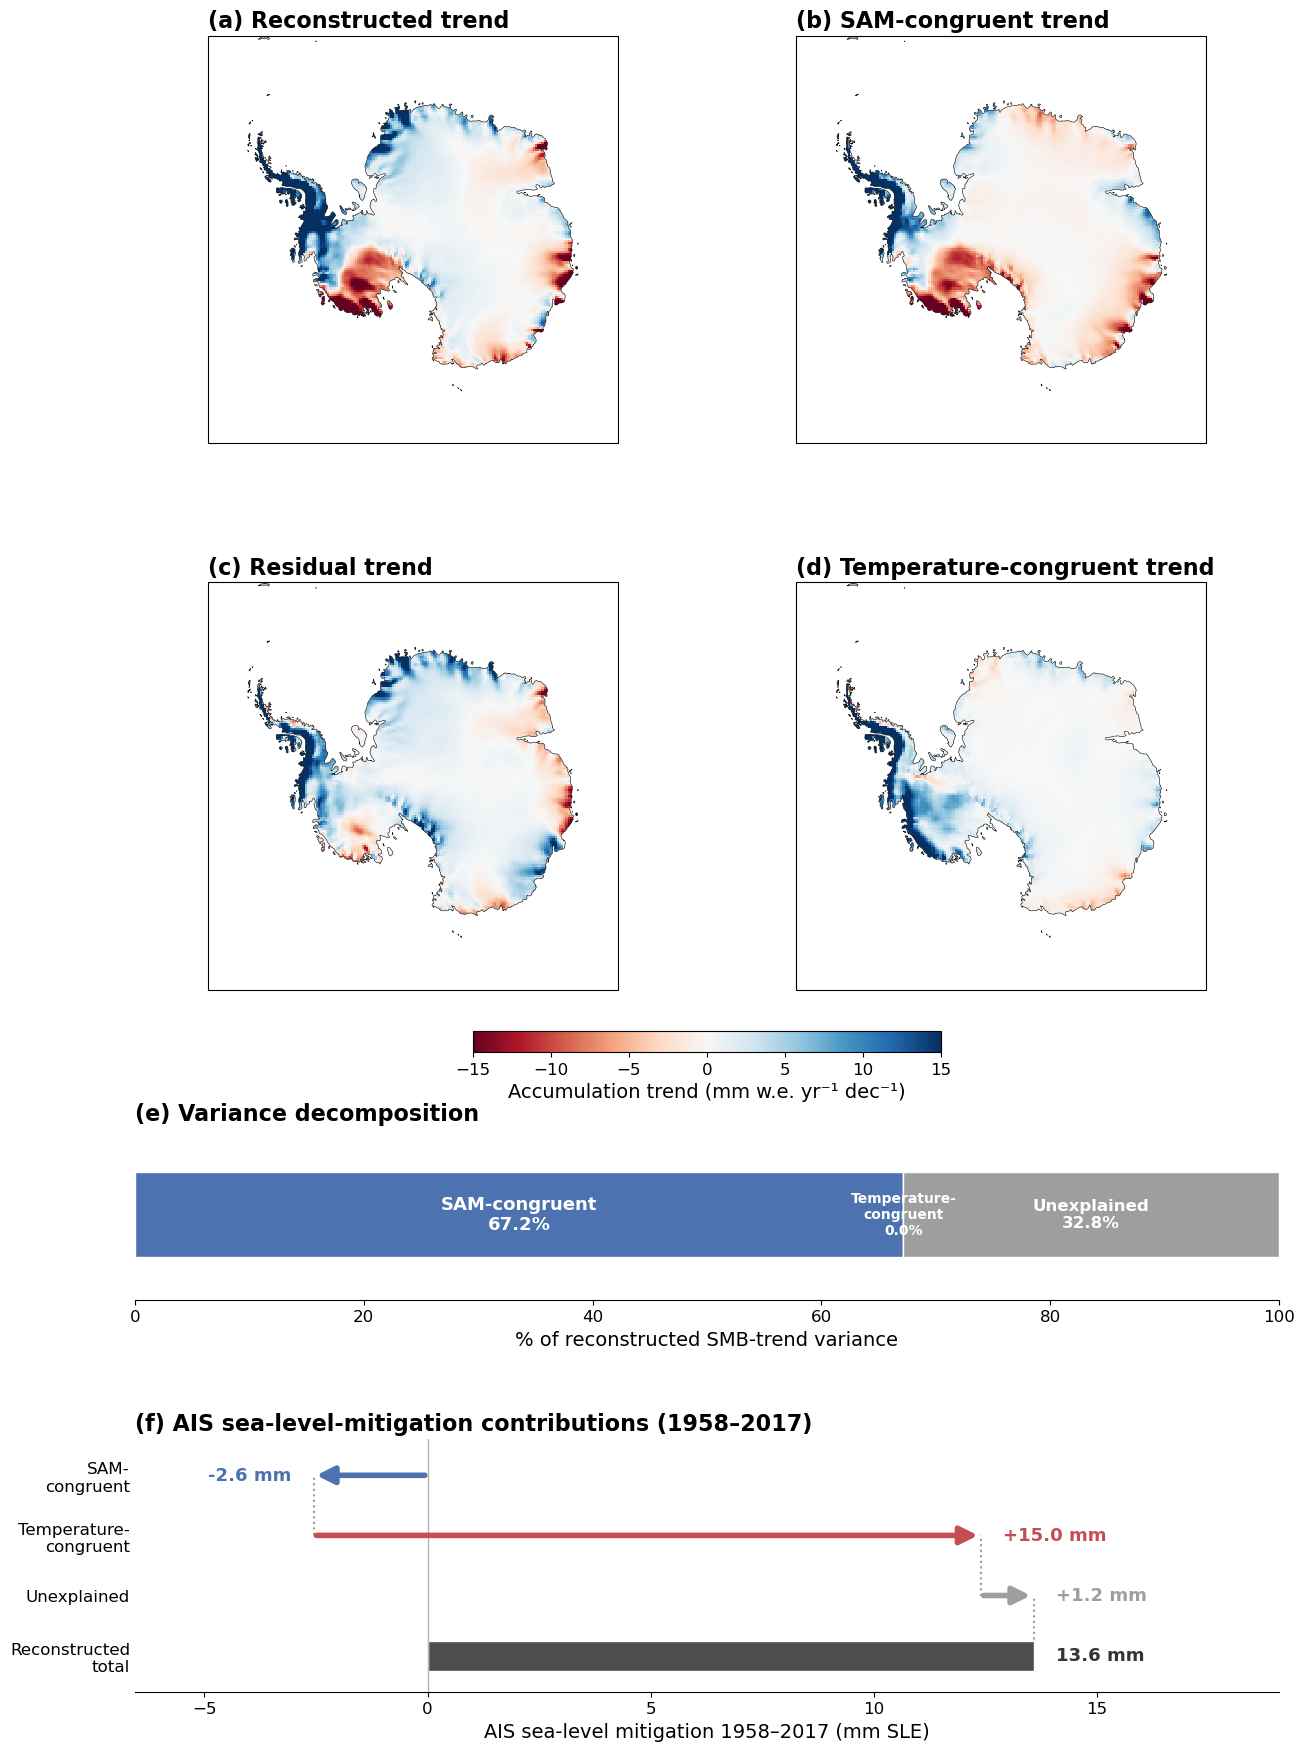

1958–2017:  SAM r²=67.2%   T(resid) r²=0.0%   → SAM 67.2% | T 0.0% | unexplained 32.8%
(f) AIS mitigation 1958–2017 = 13.6 mm  =  SAM -2.6 + Temperature +15.0 + Unexplained +1.2 mm


In [23]:
# ===== SAM decomposition + temperature-congruent trend + variance decomposition — recon+RACMO, 1958–2017 =====
import cartopy.crs as ccrs, cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
GT = 361.8
def rc(a, b): m = np.isfinite(a) & np.isfinite(b); return np.corrcoef(a[m], b[m])[0, 1]

# joined per-cell SMB: reconstruction 1958–2000, raw RACMO 2001–2017
rec_part = racmo_smb_recon.reshape(200, -1)[1958-1801:2000-1801+1][:, valid_cells]      # 1958–2000
rac_part = smb_ann.sel(year=slice(2001, 2017)).values.reshape(-1, NY*NX)[:, valid_cells]  # 2001–2017
joined   = np.vstack([rec_part, rac_part])                                               # 1958–2017 (68 yr)
recon_tr = trend_cols(joined) * 10

sam_tr   = np.polyfit(np.arange(len(sam.loc[1958:2017])), sam.loc[1958:2017].values, 1)[0] * 10
samcong  = SAMsens_rate * sam_tr; resid = recon_tr - samcong
pred_brom = Tsens_rate * brom_trend(1958, 2017)[ii]
r_res, r_sam = rc(resid, pred_brom), rc(recon_tr, samcong)
r_sam2, r_res2 = 100*r_sam**2, 100*r_res**2

vlim = 15
panels = [("(a) Reconstructed trend", recon_tr), ("(b) SAM-congruent trend", samcong),
          ("(c) Residual trend", resid), ("(d) Temperature-congruent trend", pred_brom)]
fig = plt.figure(figsize=(13, 18))
gs = gridspec.GridSpec(4, 2, height_ratios=[1, 1, 0.42, 0.62], hspace=0.45, wspace=0.06,
                       left=0.06, right=0.94, top=0.97, bottom=0.05)
map_axes = []
for idx, (title, field) in enumerate(panels):
    ax = fig.add_subplot(gs[idx//2, idx % 2], projection=ccrs.SouthPolarStereo()); map_axes.append(ax)
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree()); ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    im = ax.pcolormesh(lon_racmo, lat_racmo, paint_cells(field), transform=ccrs.PlateCarree(),
                       cmap="RdBu", vmin=-vlim, vmax=vlim, shading="nearest", zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=2); ax.add_feature(cfeature.COASTLINE, lw=0.4, zorder=3)
    ax.set_title(title, fontsize=16, fontweight="bold", loc="left")

# --- (e) single variance-decomposition bar (all shares of TOTAL, sum to 100%) ---
axe = fig.add_subplot(gs[2, :])
C_SAM, C_T, C_U = "#4C72B0", "#C44E52", "#9e9e9e"
S = r_sam2; Rr = 100 - S; T = r_res2/100 * Rr; U = Rr - T
axe.barh(0, S, left=0,   height=0.5, color=C_SAM, edgecolor="white")
axe.barh(0, T, left=S,   height=0.5, color=C_T,   edgecolor="white")
axe.barh(0, U, left=S+T, height=0.5, color=C_U,   edgecolor="white")
axe.text(S/2,     0, f"SAM-congruent\n{S:.1f}%",              ha="center", va="center", color="white", fontweight="bold", fontsize=13)
axe.text(S+T/2,   0, f"Temperature-\ncongruent\n{T:.1f}%",   ha="center", va="center", color="white", fontweight="bold", fontsize=10)
axe.text(S+T+U/2, 0, f"Unexplained\n{U:.1f}%",               ha="center", va="center", color="white", fontweight="bold", fontsize=12)
axe.set_xlim(0, 100); axe.set_ylim(-0.5, 0.5); axe.set_yticks([])
axe.set_xlabel("% of reconstructed SMB-trend variance", fontsize=14); axe.tick_params(axis="x", labelsize=12)
for sp in ("top", "right", "left"): axe.spines[sp].set_visible(False)
axe.set_title("(e) Variance decomposition", fontsize=16, fontweight="bold", loc="left")

# --- (f) AIS sea-level-mitigation contributions over the ATTRIBUTION window 1958–2017 ---
axf = fig.add_subplot(gs[3, :])
fmask = np.isfinite(recon_tr) & np.isfinite(samcong) & np.isfinite(pred_brom)
def _ig(fld): return (A_smb @ np.where(fmask, fld, 0.0))[0]                # AIS = region index 0
tot_tr = _ig(recon_tr)
f_S, f_T = _ig(samcong)/tot_tr, _ig(pred_brom)/tot_tr; f_U = 1 - f_S - f_T
comb = pd.concat([pd.Series(recon_series["AIS"], index=recon_years).loc[:1978], raw_series["AIS"].loc[1979:2017]])
mit  = pd.Series(np.cumsum(comb.loc[1901:2017].values - comb.loc[1801:1900].mean())/GT, index=np.arange(1901, 2018))
mit_tot = mit.loc[2017] - mit.loc[1957]                                    # mitigation accrued 1958–2017
cS, cT, cU = mit_tot*f_S, mit_tot*f_T, mit_tot*f_U

steps = [("SAM-\ncongruent", cS, C_SAM), ("Temperature-\ncongruent", cT, C_T), ("Unexplained", cU, C_U)]
ypos = [3, 2, 1]                                                            # rows, top → bottom
run = 0.0
for (lab, val, col), y in zip(steps, ypos):
    axf.annotate("", xy=(run+val, y), xytext=(run, y),
                 arrowprops=dict(arrowstyle="-|>", color=col, lw=4, mutation_scale=26))
    axf.plot([run+val, run+val], [y-1, y], ls=":", color="0.6", lw=1.5, zorder=0)       # connector to next row
    dx, ha = (0.5, "left") if val >= 0 else (-0.5, "right")
    axf.text(run+val+dx, y, f"{val:+.1f} mm", ha=ha, va="center", fontweight="bold", fontsize=13, color=col)
    run += val
axf.barh(0, mit_tot, height=0.5, color="0.3", edgecolor="white", zorder=1)              # accrued 1958–2017 total
axf.text(mit_tot+0.5, 0, f"{mit_tot:.1f} mm", ha="left", va="center", fontweight="bold", fontsize=13, color="0.2")
axf.axvline(0, color="0.7", lw=1)
xs = [0, cS, cS+cT, mit_tot]
axf.set_ylim(-0.6, 3.6); axf.set_xlim(min(xs)-4.0, max(xs)+5.5)
axf.set_yticks([3, 2, 1, 0]); axf.set_yticklabels([s[0] for s in steps] + ["Reconstructed\ntotal"], fontsize=12)
axf.set_xlabel("AIS sea-level mitigation 1958–2017 (mm SLE)", fontsize=14)
axf.tick_params(axis="x", labelsize=12); axf.tick_params(axis="y", length=0)
for sp in ("top", "right", "left"): axf.spines[sp].set_visible(False)
axf.set_title("(f) AIS sea-level-mitigation contributions (1958–2017)", fontsize=16, fontweight="bold", loc="left")

p2 = map_axes[2].get_position(); pe = axe.get_position(); gap = p2.y0 - pe.y1
cax = fig.add_axes([0.32, pe.y1 + 0.55*gap, 0.36, 0.012])
cb = fig.colorbar(im, cax=cax, orientation="horizontal")
cb.set_label("Accumulation trend (mm w.e. yr⁻¹ dec⁻¹)", fontsize=14); cb.ax.tick_params(labelsize=12)
plt.show()
print(f"1958–2017:  SAM r²={r_sam2:.1f}%   T(resid) r²={r_res2:.1f}%   "
      f"→ SAM {S:.1f}% | T {T:.1f}% | unexplained {U:.1f}%")
print(f"(f) AIS mitigation 1958–2017 = {mit_tot:.1f} mm  =  SAM {cS:+.1f} + Temperature {cT:+.1f} + Unexplained {cU:+.1f} mm")


## 8 · Not yet ported\nThe GRACE / ISMIP6 mass-balance comparison and the reanalysis/skill validation maps are **not** included in this version: GRACE needs its mascon mask rebuilt on the MAR grid, and ISMIP6 starts in 2016 (only ~1 yr overlap with MAR's 2017 end) — that panel needs a to-present MAR run (e.g. MARv3.11 ERA5). The GRACE comparison itself works over 2002–2017 once its mask is ported. Ask to add these next.